In [ ]:
print('Running imports...')

import torch # long
import os
import numpy as np
import lightning as L
from torch.utils.data import DataLoader, TensorDataset, random_split
import xarray as xr
from models.model import Wang2024
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import seed_everything
import wandb
from models.lightning import LitCNN_regression, AttributableTrainer,LogPlotsRegression
from models.losses import DistribLoss, PinballLoss, WeightedOrdinalLoss, logits_to_class_probs, SortedMSELoss, CompositeQuantileLoss, HybridMSEQuantileLoss, PinballLossSquare, WeightedMSELoss, LogMSE,WeightedLogMSELoss, WeightedSqrtMSELoss, AsymmetricMSELoss, AsymmetricMSEabveThreshLoss
import random
import matplotlib
from models.data import get_input_data, get_input_data_small,get_input_data_small_extended
import pandas as pd
import cartopy.crs as ccrs
from models.attributions import log_attribution_regression

# matplotlib.use('tkagg')



seed_everything(42, workers=True)

learning_rate = 0.001
batch_size = 512
num_epochs = 20
device = 'cuda:1'
input_variable = ['u850','v850','z500']
groups = 3
loss_fn = 'asymetric_mse_thresh'
region_predicted = 14
type_prediction='regression'
lags = 1
input_type='small_extended'
attribute_test = True
augment_train_set = False
data_type='anomaly'
log_rain_prediction = False


# loss = PinballLoss([0.25, 0.5, 0.75])

num_classes =  3


config = {
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "num_classes": num_classes,
    "learning_rate":learning_rate,
    "input_variable" :input_variable,
    "number_variables":len(input_variable),
    "groups" : groups,
    "lags":lags,
    "region_predicted":region_predicted,
    "type_prediction":type_prediction,
    "loss_fn":loss_fn,
    "input_type":input_type,
    "augment_train_set":augment_train_set,
    "data_type":data_type,
    "log_rain_prediction":log_rain_prediction
    }



wandb_logger = WandbLogger(project="Predict-rain-WNorway", 
                           save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                           dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                           config=config, name=f"CNN-{type_prediction} {'-'.join(input_variable)} lag {lags}")
# wandb_logger = WandbLogger(project="Predict-rain-WNorway", config=config, name="Truth")

print('Loading data ...')
if input_type=='small':
    image_size = 32*32
    train_loader, valid_loader, test_loader, ds_test = get_input_data_small(config['input_variable'], config['region_predicted'], config['type_prediction'], config['batch_size'], lags=lags, augment_train_set=augment_train_set)
if input_type=='small_extended':
    image_size = 32*64
    train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended(config['input_variable'], config['region_predicted'], config['type_prediction'], config['batch_size'], lags=lags, augment_train_set=augment_train_set)
elif input_type=='big':
    image_size=100*256
    train_loader, valid_loader, test_loader = get_input_data(config['input_variable'], config['region_predicted'], config['type_prediction'], config['batch_size'], lags=lags)
 
print('Data ready')

# callbacks=[LogPlotsRegression()]
callbacks=[]

trainer = AttributableTrainer(limit_train_batches=100, max_epochs=num_epochs, logger=wandb_logger, 
                              log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                              callbacks=callbacks, deterministic=True,
                              accelerator="gpu", devices=1)


Seed set to 42


Running imports...
Loading data ...
Data ready


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [400]:

trainer = AttributableTrainer(limit_train_batches=100, max_epochs=num_epochs, logger=wandb_logger, 
                              log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                              callbacks=callbacks, deterministic=True,
                              accelerator="gpu", devices=1)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:

class Wang2024(nn.Module):
    def __init__(self, num_classes,num_channels_in, image_size, groups=3):
        super().__init__()
        self.num_classes = num_classes
        self.conv1 = nn.Conv2d(in_channels=num_channels_in, out_channels=12, kernel_size=3, stride=1, padding=1, groups=groups)
        self.conv1_bn = nn.BatchNorm2d(12)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=48, kernel_size=3, stride=1, padding=1, groups=1)
        self.conv2_bn = nn.BatchNorm2d(48)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        cnn_channels = 48
        max_pools = 4*4
        self.linear_size = image_size * cnn_channels // max_pools 
        self.fc1 = nn.Linear(self.linear_size, 96)
        self.fc2 = nn.Linear(96, 48)
        self.fc3 = nn.Linear(48, num_classes)
        self.dropout = nn.Dropout(0.1)
    def forward(self, x):
        x = self.conv1(x)
        # x = self.conv1_bn(x)
        x = nn.ReLU()(x)
        # x = self.dropout(x)
        x = self.pool1(x)
        x = self.conv2(x)
        # x = self.conv2_bn(x)
        x = nn.ReLU()(x)
        # x = self.dropout(x)
        x = self.pool2(x)
        x = x.view((-1,self.linear_size))
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        x = nn.ReLU()(x)
        x = self.fc3(x)        
        x = nn.functional.leaky_relu(x, negative_slope=0.01)
        x = nn.functional.softplus(x)
        return x
    

In [401]:

quantiles_list = [.10,.2,.3,.4,.5,.6,.7,.8,.9,.95,.99,.999]
num_output_neurons = len(quantiles_list)

CNN = Wang2024(num_classes=num_output_neurons, num_channels_in=len(config['input_variable']), image_size=image_size, 
               groups=config['groups'])

from torch import nn
class QuantileLoss(nn.Module):
    def __init__(self, quantiles=[0.25, 0.5, 0.75]):
        super(QuantileLoss, self).__init__()
        self.quantiles = torch.tensor(quantiles).view(1, -1).to('cuda')  # Shape (1, 3) to match preds

    def forward(self, preds, target):
        """
        preds: Tensor of shape (batch_size, 3) -> Predicted quantiles (q=0.25, 0.5, 0.75)
        target: Tensor of shape (batch_size, 1) -> True values (scalar rainfall)
        """
        target = target.expand_as(preds)  # Expand target to shape (batch_size, 3)
        errors = target - preds  # Compute residuals (y - y_pred)

        loss = torch.maximum(self.quantiles * errors, (1 - self.quantiles) * -errors)  # Apply quantile loss
        return loss.mean()  # Average over all quantiles and batch

loss = QuantileLoss(quantiles=quantiles_list)
model = LitCNN_regression(CNN, 
                         learning_rate=config['learning_rate'], 
                         loss_fn = loss)

In [402]:
print('Model init')
trainer.fit(model, train_loader, valid_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type         | Params | Mode 
-------------------------------------------------
0 | model   | Wang2024     | 600 K  | train
1 | loss_fn | QuantileLoss | 0      | train
-------------------------------------------------
600 K     Trainable params
0         Non-trainable params
600 K     Total params
2.403     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Model init


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [403]:

model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           0.9220572710037231
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [404]:
truth = torch.stack(model.test_step_true_values).cpu().numpy().squeeze()
pred = torch.stack(model.test_step_pred).cpu().numpy().squeeze()

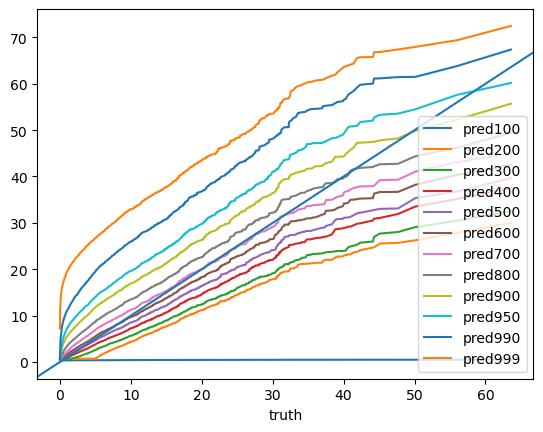

In [405]:
import matplotlib.pyplot as plt
df = pd.DataFrame(pred, columns = 'pred'+(np.array(quantiles_list)*1000).astype(int).astype(str))
df['truth'] = truth
df_ext = df.loc[df.truth>0].sort_values('truth').reset_index()
# df_ext.truth.plot()
# df_ext.pred95.plot()
# plt.plot(pred[1,:])
# fig, axs = plt.subplots()
# df_ext.truth.plot(ax=axs)
# axs.fill_between(df_ext.index, df_ext.pred750, df_ext.pred95, color='tab:red', alpha=.3)

fig, axs = plt.subplots()
df.transform(np.sort).set_index('truth').plot( ax=axs)

axs.axline((0,0), slope=1)
ds = df.iloc[:,:-1].to_xarray().to_array().rename(variable='quantiles').assign_coords(quantiles=quantiles_list).rename('pred').to_dataset()
# (ds>ds.truth).mean('index')
ds['truth'] = df.iloc[:,-1].to_xarray()

In [390]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'quantiles' is your xarray.DataArray with dimensions ('index', 'quantile')
# Example: quantiles.shape could be (n_indices, n_quantiles), where 'n_indices' is your sample size or locations,
# and 'n_quantiles' is the number of quantiles (e.g., 10th, 50th, 90th percentiles)

# 1. Create the CDF values corresponding to quantiles (linearly spaced between 0 and 1)
quantiles = ds.pred  # Keep it as xarray.DataArray

# Define the CDF values for the quantile dimension (assumes uniform spacing)
cdf_values = xr.DataArray(np.linspace(0, 1, quantiles.shape[0]), dims="quantiles", coords={"quantiles": quantiles.quantiles})

# 2. Calculate the PDF by differentiating the CDF with respect to the quantiles
# We use xarray's .diff() method to compute differences between adjacent quantiles along the 'quantile' dimension
pdf_values = cdf_values.diff("quantiles",) / quantiles.diff("quantiles")

# 3. Handle edge cases (pad the PDF array for the last quantile if necessary)
pdf_values = pdf_values.pad(quantile=("both", 1), mode="constant", constant_values=0)

# 4. Plotting the estimated PDF for a specific index
index_value = 0  # Choose the index you want to plot (e.g., the first index)
# plt.plot(quantiles.sel(index=index_value), pdf_values.sel(index=index_value), label=f'Index {index_value}')
# plt.xlabel('Quantile Value')
# plt.ylabel('Estimated PDF')
# plt.title(f'Estimated PDF from Quantiles (Index {index_value})')
# plt.legend()
# plt.show()


In [357]:
ds_pred_inetrp = ds.pred.interp(quantiles=np.arange(0.1,1,0.001),method='cubic' )

In [358]:
from scipy.interpolate import interp1d

In [377]:
y

DataArrayRolling [quantiles->3(center)]

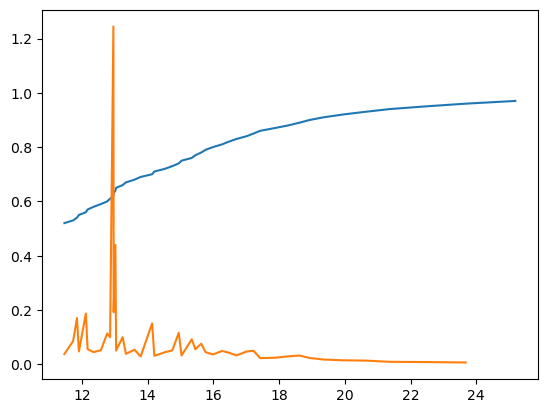

In [396]:
y = ds.pred.isel(index=10).rolling(quantiles=5, center=True).mean()
x = ds.quantiles
# plt.plot(y-y[:1])
# plt.plot(y,x)
plt.plot(y,x)
plt.plot(y,(x.shift(quantiles=-1)-x)/(y.shift(quantiles=-1)-y))
# x_ = np.arange(0.1,.999,0.01)
# f = interp1d(x,y, 'slinear')
# y_ = f(x_)
# plt.plot(y_[1:], (x_[1:]-x_[:-1])/(y_[1:]-y_[:-1]))

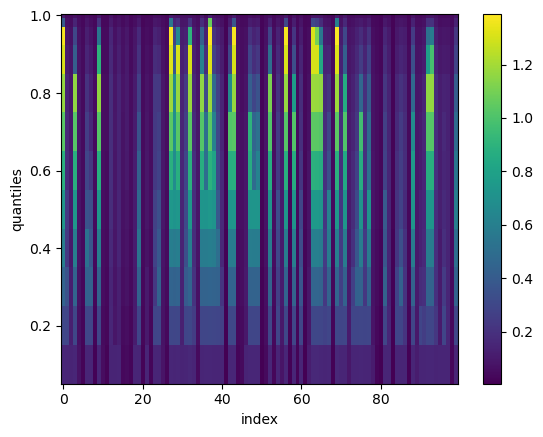

In [269]:
(ds.quantiles.diff('quantile')/ds.pred.diff('quantile')).isel(index=range(100)).plot()

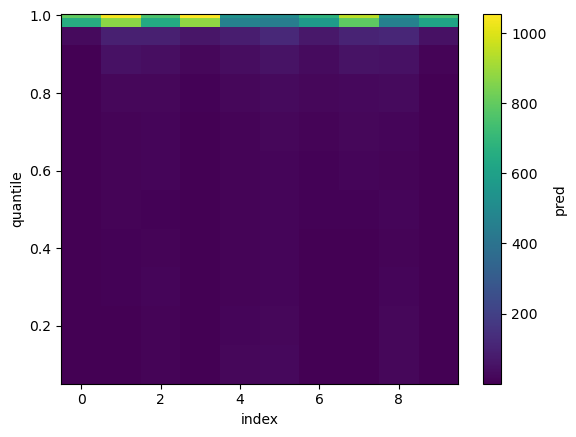

In [214]:
ds.pred.isel(index=range(10)).differentiate('quantile').plot(y='quantile')

In [ ]:
df.iloc[:,:-1].to_xarray().to_array().rename(variable='quantiles').assign_coords(quantiles=quqnt)

<xarray.DataArray (quantiles: 12, index: 4602)> Size: 221kB
array([[ 0.6482776 ,  0.6715819 ,  0.6921776 , ...,  0.6856934 ,
         6.5773783 ,  0.9568628 ],
       [ 0.6733392 ,  0.6880706 ,  1.6508006 , ...,  1.0890782 ,
         9.254875  ,  2.9731932 ],
       [ 0.67488617,  0.8458852 ,  2.5928984 , ...,  2.0332153 ,
        10.637303  ,  3.9679043 ],
       ...,
       [ 0.6924533 , 11.066125  , 13.710382  , ..., 13.253765  ,
        21.290136  , 14.0482235 ],
       [ 2.4838572 , 15.826608  , 18.915316  , ..., 19.004223  ,
        27.457933  , 19.639053  ],
       [ 9.650435  , 25.199898  , 25.728542  , ..., 25.794277  ,
        30.896263  , 24.394117  ]], dtype=float32)
Coordinates:
  * index      (index) int64 37kB 0 1 2 3 4 5 ... 4596 4597 4598 4599 4600 4601
  * quantiles  (quantiles) object 96B 'pred100' 'pred200' ... 'pred999'

In [199]:
# ds.where(ds.pred>ds.truth).isel(index=50).pred.plot()
# ds.where(ds.pred>ds.truth).isel(index=50).truth.plot()

q_max = ds.where(ds.pred>ds.truth).pred.idxmin('quantile')
q_min = ds.where(ds.pred<ds.truth).pred.idxmax('quantile')


(array([1362.,  230.,  249.,  319.,  296.,  314.,  282.,  376.,  559.,
         598.]),
 array([0.1   , 0.1899, 0.2798, 0.3697, 0.4596, 0.5495, 0.6394, 0.7293,
        0.8192, 0.9091, 0.999 ]),
 <BarContainer object of 10 artists>)

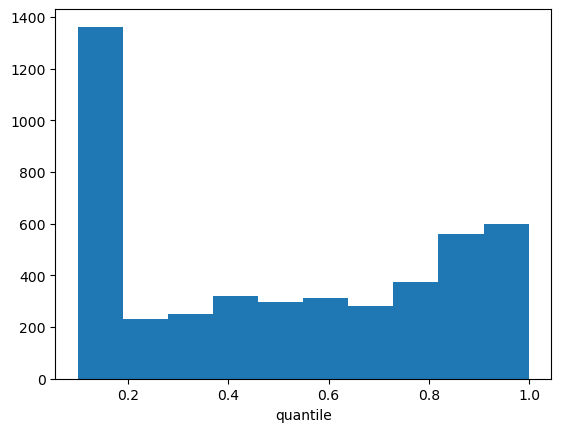

In [201]:
q_max.plot.hist()

(0.0, 100.0)

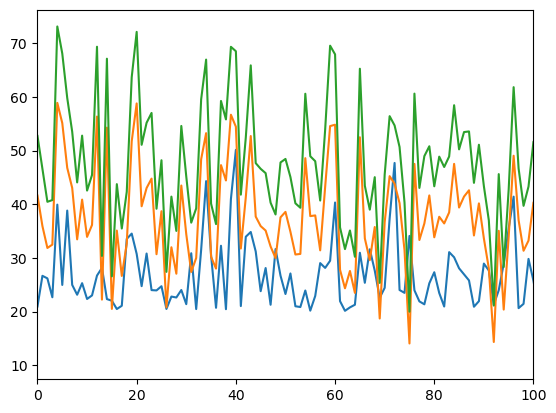

In [132]:
df_ext = df.loc[df.truth>20].reset_index()
df_ext.truth.plot()
df_ext.pred990.plot()
df_ext.pred999.plot()

plt.xlim(0,100)

In [122]:
df.pred99

,pred99,pred99
0,3.032691,7.592142
1,17.271740,24.802540
2,15.182031,21.731358
3,6.111965,12.165840
4,19.204243,25.614822
...,...,...
4597,3.469922,7.041981
4598,6.915887,11.821756
4599,17.067362,23.916229
4600,31.139418,39.820595
